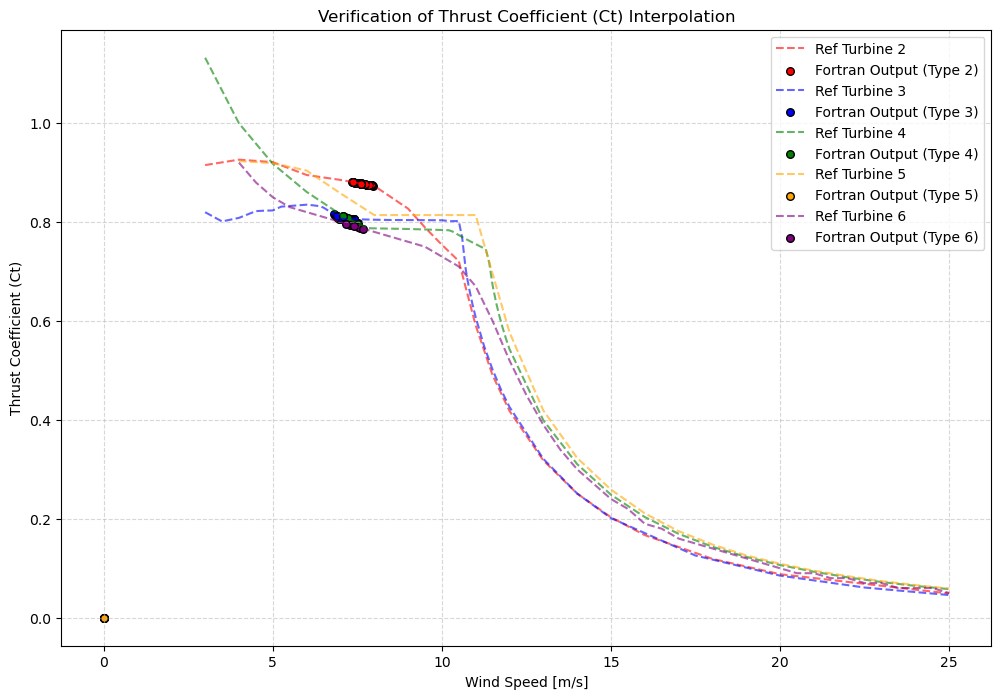

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ۱. تنظیمات اولیه و آدرس فایل‌ها
debug_file = 'debug_coeffs.csv'
# لیست فایل‌های اصلی توربین‌ها به ترتیب ایندکسی که در فرترن دارید
# توجه: اگر در فرترن ایندکس ۱ توربین Dummy است، لیست را از ایندکس ۲ شروع کنید
turbine_files = {
    2: '../../Turbines/IEA_Reference_10MW_198.csv',
    3: '../../Turbines/IEA_Reference_15MW_240.csv',
    4: '../../Turbines/NREL_Reference_5MW_126.csv',
    5: '../../Turbines/DTU_Reference_v1_10MW_178.csv',
    6: '../../Turbines/LEANWIND_Reference_8MW_164.csv'
}

def plot_verification():
    # ۲. خواندن فایل دیباگ فرترن
    if not os.path.exists(debug_file):
        print(f"Error: {debug_file} not found!")
        return

    # فرض بر این است که فایل سه ستون دارد: Type, WindSpeed, Ct
    df_debug = pd.read_csv(debug_file, names=['Type', 'WindSpeed', 'Ct'])

    # ۳. رسم نمودار
    plt.figure(figsize=(12, 8))
    
    # رنگ‌های مختلف برای توربین‌های مختلف
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for i, (t_type, file_path) in enumerate(turbine_files.items()):
        if not os.path.exists(file_path):
            print(f"Warning: Reference file {file_path} not found. Skipping...")
            continue
            
        # الف) خواندن داده مرجع (اصلی)
        df_ref = pd.read_csv(file_path)
        
        # پیدا کردن نام ستون‌ها (چون در فایل‌های مختلف ممکن است متفاوت باشد)
        v_col = [c for c in df_ref.columns if 'Wind' in c][0]
        ct_col = [c for c in df_ref.columns if 'Ct' in c or 'Thrust Coefficient' in c][0]
        
        # رسم منحنی مرجع به صورت خط ممتد
        plt.plot(df_ref[v_col], df_ref[ct_col], label=f'Ref Turbine {t_type}', 
                 linestyle='--', alpha=0.6, color=colors[i])
        
        # ب) فیلتر کردن داده‌های دیباگ برای این توربین خاص
        df_sub_debug = df_debug[df_debug['Type'] == t_type]
        
        # رسم نقاط خروجی فرترن به صورت نقطه (Scatter)
        if not df_sub_debug.empty:
            plt.scatter(df_sub_debug['WindSpeed'], df_sub_debug['Ct'], 
                        color=colors[i], label=f'Fortran Output (Type {t_type})', 
                        s=30, edgecolors='black')

    plt.title('Verification of Thrust Coefficient (Ct) Interpolation')
    plt.xlabel('Wind Speed [m/s]')
    plt.ylabel('Thrust Coefficient (Ct)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()

if __name__ == "__main__":
    plot_verification()

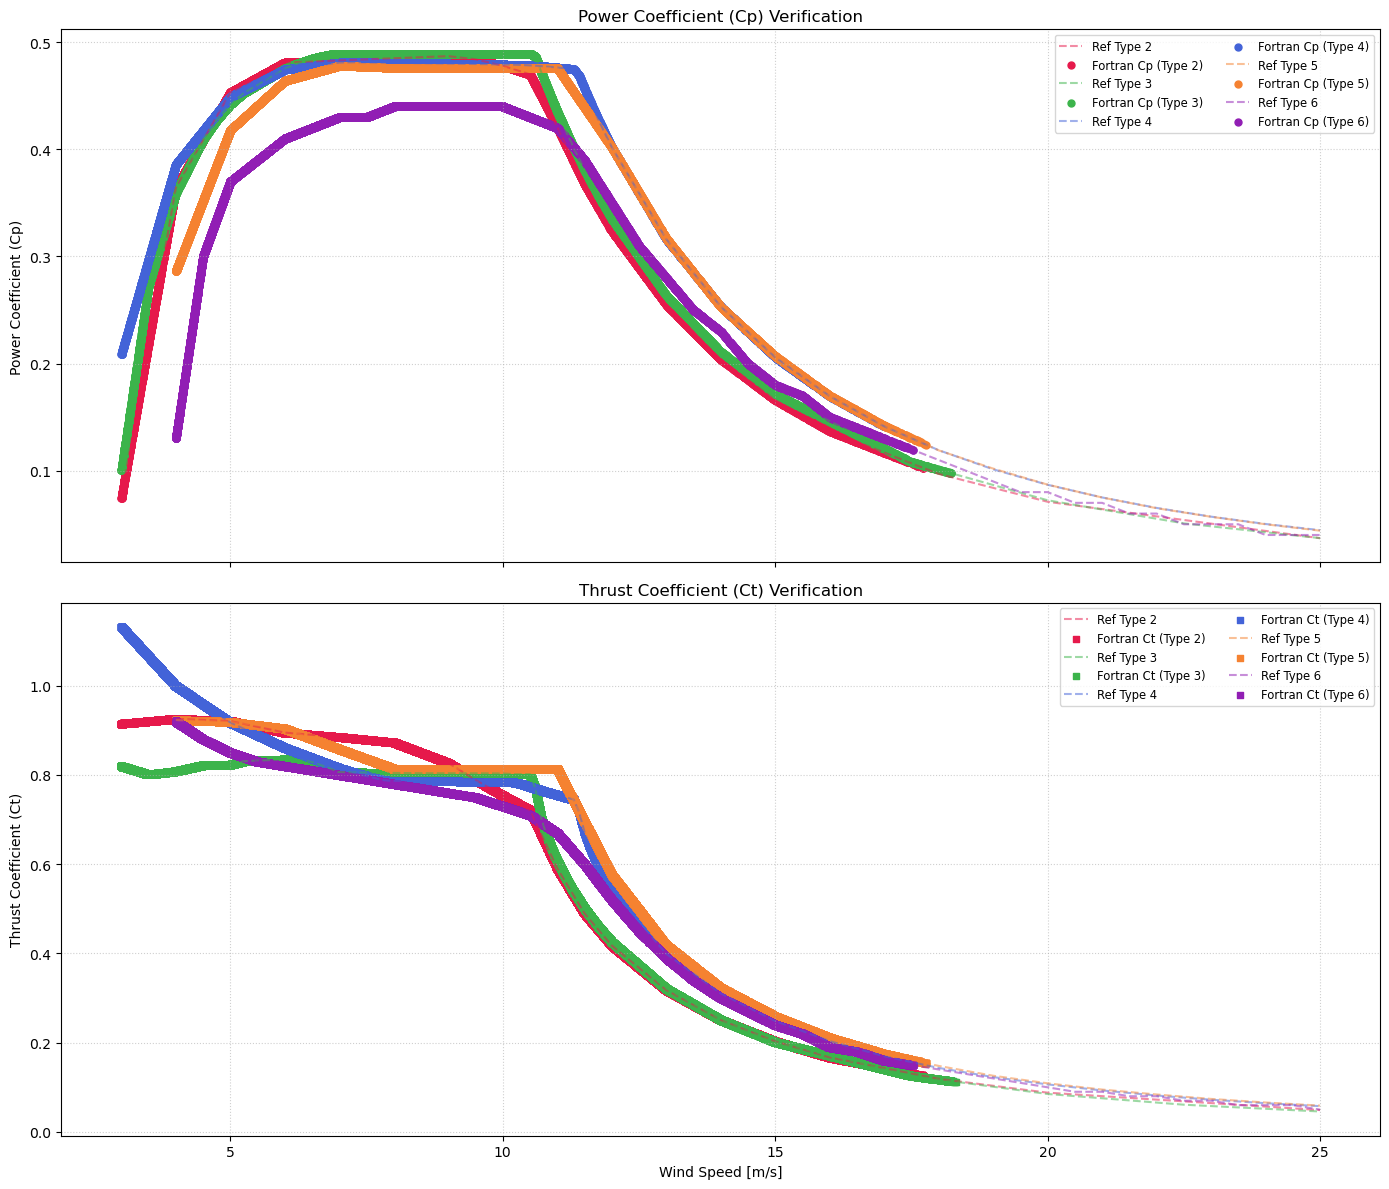

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Configuration
debug_file = 'debug_coeffs.csv'

# Dictionary mapping turbine type ID to the CSV file path
# Indices correspond to the order in turbine_spec.txt (starting at 2 for real turbines)
turbine_files = {
    2: '../../Turbines/IEA_Reference_10MW_198.csv',
    3: '../../Turbines/IEA_Reference_15MW_240.csv',
    4: '../../Turbines/NREL_Reference_5MW_126.csv',
    5: '../../Turbines/DTU_Reference_v1_10MW_178.csv',
    6: '../../Turbines/LEANWIND_Reference_8MW_164.csv'
}

def find_column(df, keywords):
    """Finds a column name in a dataframe based on keywords."""
    for col in df.columns:
        if any(key.lower() in col.lower() for key in keywords):
            return col
    return None

def plot_comprehensive_verification():
    if not os.path.exists(debug_file):
        print(f"Error: {debug_file} not found!")
        return

    # 2. Read the Fortran Debug Output
    # Columns: Type, WindSpeed, CoeffValue, Choice (1=Cp, 2=Ct)
    df_debug = pd.read_csv(debug_file, names=['Type', 'WindSpeed', 'Val', 'Choice'])

    # 3. Setup Plotting Environment
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    
    for i, (t_type, file_path) in enumerate(turbine_files.items()):
        if not os.path.exists(file_path):
            print(f"Warning: Reference file {file_path} not found. Skipping...")
            continue
            
        # 4. Load Reference Data
        df_ref = pd.read_csv(file_path)
        
        # Identify columns dynamically (handles differences in naming between files)
        v_col = find_column(df_ref, ['Wind'])
        cp_col = find_column(df_ref, ['Cp', 'Power Coeff'])
        ct_col = find_column(df_ref, ['Ct', 'Thrust Coeff'])

        if not all([v_col, cp_col, ct_col]):
            print(f"Error: Could not find required columns in {file_path}")
            continue

        # 5. Plot Reference Lines
        ax1.plot(df_ref[v_col], df_ref[cp_col], label=f'Ref Type {t_type}', 
                 linestyle='--', color=colors[i], alpha=0.5)
        ax2.plot(df_ref[v_col], df_ref[ct_col], label=f'Ref Type {t_type}', 
                 linestyle='--', color=colors[i], alpha=0.5)

        # 6. Plot Fortran Interpolated Points
        # Filter debug data for this turbine and specific coefficient type
        debug_cp = df_debug[(df_debug['Type'] == t_type) & (df_debug['Choice'] == 1)]
        debug_ct = df_debug[(df_debug['Type'] == t_type) & (df_debug['Choice'] == 2)]

        if not debug_cp.empty:
            ax1.scatter(debug_cp['WindSpeed'], debug_cp['Val'], color=colors[i], 
                        marker='o', s=25, label=f'Fortran Cp (Type {t_type})')
        
        if not debug_ct.empty:
            ax2.scatter(debug_ct['WindSpeed'], debug_ct['Val'], color=colors[i], 
                        marker='s', s=25, label=f'Fortran Ct (Type {t_type})')

    # 7. Formatting
    ax1.set_ylabel('Power Coefficient (Cp)')
    ax1.set_title('Power Coefficient (Cp) Verification')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right', fontsize='small', ncol=2)

    ax2.set_ylabel('Thrust Coefficient (Ct)')
    ax2.set_xlabel('Wind Speed [m/s]')
    ax2.set_title('Thrust Coefficient (Ct) Verification')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right', fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_comprehensive_verification()

Loading debug data...
Saving high-resolution plots...


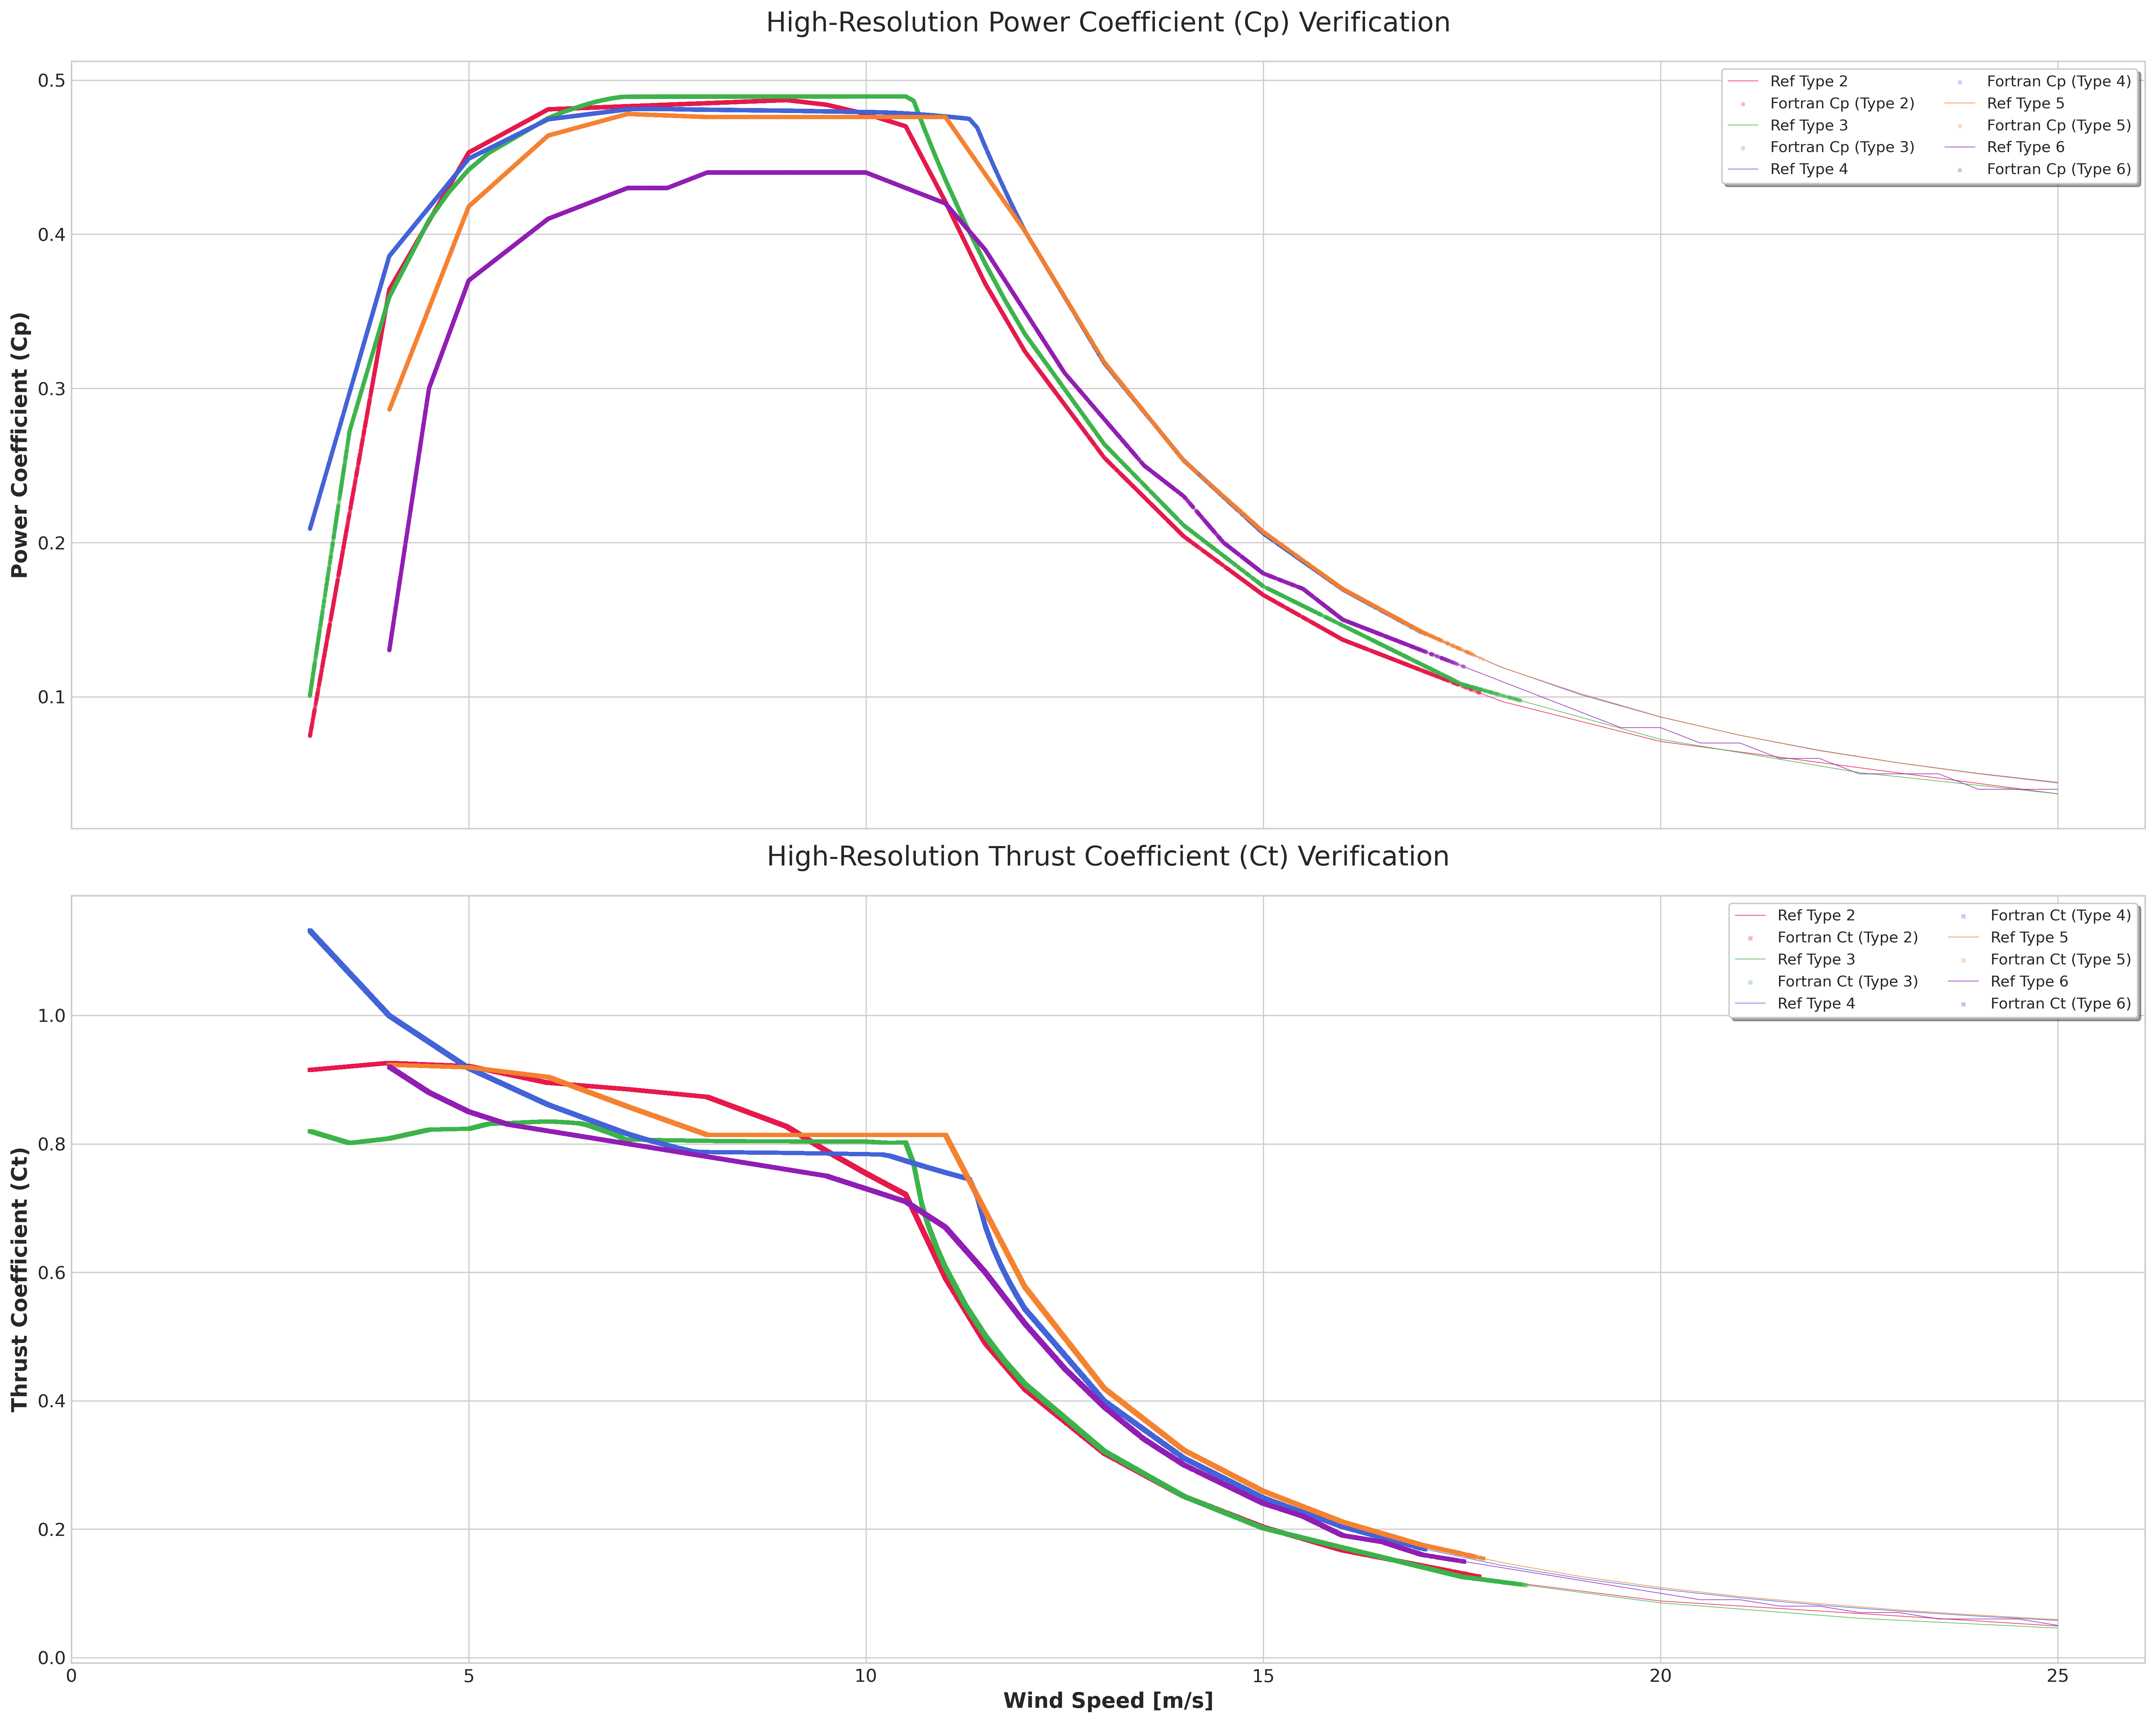

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Configuration
debug_file = 'debug_coeffs.csv'
# Increased DPI for much higher resolution
PLOT_DPI = 300 
# Figure size (Width, Height in inches) - Very large for detail
BIG_FIG_SIZE = (20, 16)

turbine_files = {
    2: '../../Turbines/IEA_Reference_10MW_198.csv',
    3: '../../Turbines/IEA_Reference_15MW_240.csv',
    4: '../../Turbines/NREL_Reference_5MW_126.csv',
    5: '../../Turbines/DTU_Reference_v1_10MW_178.csv',
    6: '../../Turbines/LEANWIND_Reference_8MW_164.csv'
}

def find_column(df, keywords):
    for col in df.columns:
        if any(key.lower() in col.lower() for key in keywords):
            return col
    return None

def plot_comprehensive_verification():
    if not os.path.exists(debug_file):
        print(f"Error: {debug_file} not found!")
        return

    # 2. Read Debug Output
    print("Loading debug data...")
    df_debug = pd.read_csv(debug_file, names=['Type', 'WindSpeed', 'Val', 'Choice'])

    # 3. Setup Plotting Environment
    # Use a dark-grid style for better contrast with many points
    plt.style.use('seaborn-v0_8-whitegrid') 
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=BIG_FIG_SIZE, sharex=True, dpi=PLOT_DPI)
    
    # High-contrast color palette
    colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    
    for i, (t_type, file_path) in enumerate(turbine_files.items()):
        if not os.path.exists(file_path):
            continue
            
        df_ref = pd.read_csv(file_path)
        v_col = find_column(df_ref, ['Wind'])
        cp_col = find_column(df_ref, ['Cp', 'Power Coeff'])
        ct_col = find_column(df_ref, ['Ct', 'Thrust Coeff'])

        # 5. Plot Reference Lines (Thicker and distinct)
        ax1.plot(df_ref[v_col], df_ref[cp_col], label=f'Ref Type {t_type}', 
                 linestyle='-', color=colors[i], linewidth=0.5, alpha=0.8, zorder=1)
        ax2.plot(df_ref[v_col], df_ref[ct_col], label=f'Ref Type {t_type}', 
                 linestyle='-', color=colors[i], linewidth=0.5, alpha=0.8, zorder=1)

        # 6. Plot Fortran Points with high-density settings
        debug_cp = df_debug[(df_debug['Type'] == t_type) & (df_debug['Choice'] == 1)]
        debug_ct = df_debug[(df_debug['Type'] == t_type) & (df_debug['Choice'] == 2)]

        # 's' is size: made smaller (8) to avoid blobs
        # 'alpha' is transparency: allows seeing through overlapping points
        # 'rasterized=True': keeps the file size small when saving as PDF/SVG 
        # while keeping points high-res
        if not debug_cp.empty:
            ax1.scatter(debug_cp['WindSpeed'], debug_cp['Val'], color=colors[i], 
                        marker='o', s=8, alpha=0.3, edgecolors='none', 
                        label=f'Fortran Cp (Type {t_type})', zorder=2, rasterized=True)
        
        if not debug_ct.empty:
            ax2.scatter(debug_ct['WindSpeed'], debug_ct['Val'], color=colors[i], 
                        marker='s', s=8, alpha=0.3, edgecolors='none', 
                        label=f'Fortran Ct (Type {t_type})', zorder=2, rasterized=True)

    # 7. Final Formatting for high-resolution output
    ax1.set_ylabel('Power Coefficient (Cp)', fontsize=14, fontweight='bold')
    ax1.set_title('High-Resolution Power Coefficient (Cp) Verification', fontsize=18, pad=20)
    
    ax2.set_ylabel('Thrust Coefficient (Ct)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Wind Speed [m/s]', fontsize=14, fontweight='bold')
    ax2.set_title('High-Resolution Thrust Coefficient (Ct) Verification', fontsize=18, pad=20)

    for ax in [ax1, ax2]:
        ax.tick_params(labelsize=12)
        ax.legend(loc='upper right', fontsize='medium', ncol=2, frameon=True, shadow=True)
        ax.set_xlim(left=0) # Wind speed starts at 0

    plt.tight_layout()
    
    # Save the figure to a file - PNG for viewing, PDF for infinite zoom
    print("Saving high-resolution plots...")
    plt.savefig('comprehensive_verification_300dpi.png', dpi=PLOT_DPI)
    # plt.savefig('comprehensive_verification.pdf') # Uncomment for vector version
    
    plt.show()

if __name__ == "__main__":
    plot_comprehensive_verification()